In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import orbax
import jax
import jax.numpy as jnp
from src.algorithms.value_iteration_and_prediction import general_value_iteration
from train_stochastic_bilevel_opt_hpgd import environment_setup
from visualization_functions import plot_UL_rewards, plot_incentive_grid

# Parameters for plotting
linewidth = 2.5
figsize = (10, 6)
plt.rcParams.update(
    {
        'font.size': 20,
        'text.usetex': True,
        'axes.linewidth': linewidth,
        'xtick.major.width': linewidth,
        'ytick.major.width': linewidth,
        'xtick.major.size': 2*linewidth,
        'ytick.major.size': 2*linewidth,
        'axes.prop_cycle': plt.cycler(color=plt.cm.Dark2.colors),
        "lines.linewidth": linewidth,
    }
)
colors = plt.cm.Dark2.colors

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Load the data

In [2]:
save_figures = True

data_dir = "data/experiment_reg_lambda_0_003_total_steps_400_"
save_dir = os.path.join(data_dir, "figures")

algorithms = ["proposal", "hpgd", "hpgd_sarsa", "sobirl", "baseline", "hpgd_oracle"]

# Note: the order in the legend follows the order in list "algorithms"

# Plot settings
max_outer_iterations = 10_000
rolling_window = 100
plot_top = 10
seed_idx = None
legend_names = {
    "proposal": r"\textsc{BC-HG}",
    "hpgd": r"\textsc{HPGD (MC)}",
    "hpgd_sarsa": r"\textsc{HPGD (SA)}",
    "hpgd_oracle": r"\textsc{HPGD (oracle)}",
    "sobirl": r"\textsc{SoBiRL}",
    "baseline": r"\textsc{Naive-PGD}",
}
line_styles = {
    "proposal": "-",
    "hpgd": "--",
    "hpgd_sarsa": "-.",
    "hpgd_oracle": ":",
    "sobirl": (0, (2, 4, 2, 4)),
    "baseline": (0, (1, 3)),
}
algo_colors = {
    "proposal": colors[2],
    "hpgd": colors[1],
    "hpgd_sarsa": colors[1],
    "hpgd_oracle": colors[0],
    "sobirl": colors[5],
    "baseline": colors[6],
}
zorder=dict(zip(legend_names.keys(), [len(legend_names)-i for i in range(len(legend_names))]))

# --- Loading Data --- #

grid_search_outputs = {}
grid_search_params = {}
grid_search_train_states = {}
summary_dfs = {}


if save_figures and not os.path.exists(save_dir):
    os.makedirs(save_dir)

with open(os.path.join(data_dir, "config.yaml"), "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

print("Experimental Config:")
print(config)

rng = jax.random.PRNGKey(config["random_seed"])

# Environment Setup
env, env_params, incentive_train_state, config_incentive = environment_setup(rng, config)

found = []
for algo in algorithms:
    try:
        print(f"\n--- {algo} ---")
        with open(os.path.join(data_dir, f"metrics_{algo}.pkl"), "rb") as f:
            outputs = pickle.load(f)
        grid_search_outputs[algo] = outputs
        with open(os.path.join(data_dir, f"grid_search_{algo}.pkl"), "rb") as f:
            grid_params = pd.DataFrame(pickle.load(f))
        grid_search_params[algo] = grid_params
        print("Grid param keys: ", grid_search_params[algo].columns)
        for k in outputs:
            if jnp.any(jnp.isnan(outputs[k])):
                print(f"\033[91m[WARNING] Found NaN values in {k} for {algo}\033[0m")

        # Load orbax checkpoint
        ckpt_path = os.path.join(data_dir, f"checkpoint_incentive_{algo}")
        orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        grid_search_train_states[algo] = orbax_checkpointer.restore(ckpt_path)
        print("Incentive Train State Loaded")
    except:
        print(f"Failed to load {algo}")
        continue

    df = grid_params.copy()
    df["UL_initial_value"] = jnp.mean(outputs["UL_initial_value"][:, -1000:], axis=1)  # average across the last 1000 steps
    df = df.set_index(list(grid_params.keys()))
    df = df.groupby(list(grid_params.keys())).mean()  # average across seeds
    df = df.sort_values("UL_initial_value", ascending=False)
    display(df)
    summary_dfs[algo] = df
    found.append(algo)

algorithms = found

Experimental Config:
{'random_seed': 0, 'num_seeds': 10, 'environment': {'name': 'ConfigurableFourRooms', 'reward_function': 'default', 'available_goals': [[1, 9]], 'available_init_pos': [[4, 1]], 'resample_init_pos_prob': [nan], 'resample_goal_probs': [nan], 'fail_prob': 0.33, 'max_steps_in_episode': 200}, 'configuration': {'incentive': {'activation_function': 'softmax', 'range': [0.0, -0.2], 'temperature': 1.0, 'coordinates': 'all'}}, 'lower_optimisation': {'algo': 'value_iteration', 'n_policy_iter': 100, 'n_value_iter': 5, 'discount_factor': 0.99, 'regularization': 'KL_divergence', 'reg_lambda': 0.003, 'reg_lambda_decay': 1.0}, 'upper_optimisation': {'discount_factor': 0.99, 'incentive_reg_param': [1.0, 2.0, 3.0, 4.0, 5.0], 'reward_function': {'type': 'positive', 'target_state': [8, 4]}, 'optimiser': 'sgd', 'max_grad_norm': 1.0, 'learning_rate': [0.5, 0.1, 0.05, 0.01], 'learning_rate_schedule': {'type': 'constant', 'args': {}}, 'smoothing_factor': [0.99, 0.9, 0.8, 0.7, 0.6, 0.5], 's

UL_initial_value
lr_grid incentive_reg_grid reg_lambda_decay sarsa_alpha_grid                  
0.50    3.0                1.0              0.5                       0.717004
        1.0                1.0              0.9                       0.678986
        3.0                1.0              0.9                       0.654435
        4.0                1.0              0.7                       0.597496
        2.0                1.0              0.9                       0.572864
...                                                                        ...
0.01    5.0                1.0              0.3                      -0.713599
                                            0.5                      -0.713794
                                            0.7                      -0.714619
                                            0.9                      -0.714820
                                            1.0                      -0.715392

[120 rows x 1 columns]


--- hpgd ---
Grid param keys:  Index(['lr_grid', 'incentive_reg_grid', 'reg_lambda_decay'], dtype='object')
Incentive Train State Loaded


,,,UL_initial_value
lr_grid,incentive_reg_grid,reg_lambda_decay,
0.05,1.0,1.0,0.773534
0.10,1.0,1.0,0.745495
0.50,1.0,1.0,0.714976
0.10,2.0,1.0,0.676366
0.05,2.0,1.0,0.634848
0.50,2.0,1.0,0.604384
0.10,3.0,1.0,0.529144
0.05,3.0,1.0,0.528071
0.50,3.0,1.0,0.503312



--- hpgd_sarsa ---
Grid param keys:  Index(['lr_grid', 'incentive_reg_grid', 'reg_lambda_decay',
       'sarsa_alpha_grid'],
      dtype='object')
Incentive Train State Loaded


...

UL_initial_value
lr_grid incentive_reg_grid reg_lambda_decay                  
0.50    5.0                1.0                       0.001281
        4.0                1.0                       0.001279
        3.0                1.0                       0.001275
        2.0                1.0                       0.001268
        1.0                1.0                       0.001241
0.10    5.0                1.0                       0.000201
        4.0                1.0                       0.000126
        3.0                1.0                      -0.000020
        2.0                1.0                      -0.000419
0.05    5.0                1.0                      -0.001811
        4.0                1.0                      -0.002325
        3.0                1.0                      -0.003681
0.10    1.0                1.0                      -0.006328
0.05    2.0                1.0                      -0.013946
        1.0                1.0                      -0.141712
0.01    1.0                1.0                      -0.144062
        2.0                1.0                      -0.288686
        3.0                1.0                      -0.432358
        4.0                1.0                      -0.574612
        5.0                1.0                      -0.713377


--- baseline ---
Grid param keys:  Index(['lr_grid', 'incentive_reg_grid', 'reg_lambda_decay'], dtype='object')
Incentive Train State Loaded


UL_initial_value
lr_grid incentive_reg_grid reg_lambda_decay                  
0.50    5.0                1.0                       0.001281
        4.0                1.0                       0.001279
        3.0                1.0                       0.001275
        2.0                1.0                       0.001268
        1.0                1.0                       0.001241
0.10    5.0                1.0                       0.000201
        4.0                1.0                       0.000126
        3.0                1.0                      -0.000020
        2.0                1.0                      -0.000419
0.05    5.0                1.0                      -0.001811
        4.0                1.0                      -0.002325
        3.0                1.0                      -0.003681
0.10    1.0                1.0                      -0.006328
0.05    2.0                1.0                      -0.013946
        1.0                1.0                      -0.141712
0.01    1.0                1.0                      -0.144062
        2.0                1.0                      -0.288686
        3.0                1.0                      -0.432358
        4.0                1.0                      -0.574612
        5.0                1.0                      -0.713377


--- hpgd_oracle ---
Grid param keys:  Index(['lr_grid', 'incentive_reg_grid', 'reg_lambda_decay'], dtype='object')
Incentive Train State Loaded


UL_initial_value
lr_grid incentive_reg_grid reg_lambda_decay                  
0.50    2.0                1.0                       0.780733
        1.0                1.0                       0.762214
0.10    1.0                1.0                       0.732852
0.05    3.0                1.0                       0.721362
0.10    3.0                1.0                       0.718156
0.01    1.0                1.0                       0.715688
0.05    1.0                1.0                       0.713562
        2.0                1.0                       0.697967
0.10    2.0                1.0                       0.694790
0.50    3.0                1.0                       0.685349
0.05    4.0                1.0                       0.624897
0.10    4.0                1.0                       0.622896
0.01    2.0                1.0                       0.622401
0.50    4.0                1.0                       0.587623
0.01    3.0                1.0                       0.535561
0.05    5.0                1.0                       0.527387
0.10    5.0                1.0                       0.526424
0.50    5.0                1.0                       0.494970
0.01    4.0                1.0                       0.480780
        5.0                1.0                       0.444067

In [3]:
# 結果を結合
combined_results = pd.DataFrame()

for algo in algorithms:
    if algo in summary_dfs:
        df = summary_dfs[algo].copy()
        df = df.reset_index()
        df['algorithm'] = algo
        combined_results = pd.concat([combined_results, df], ignore_index=True)

# incentive_reg_gridでピボットして見やすくする
if not combined_results.empty:
    pivot_table = combined_results.pivot_table(
        values='UL_initial_value',
        index=['incentive_reg_grid','lr_grid'], 
        columns='algorithm',
        aggfunc='first'
    )
    
    print("Combined Results Table")
    print("=" * 60)
    print(pivot_table.to_string())
    

Combined Results Table
algorithm                   baseline      hpgd  hpgd_oracle  hpgd_sarsa  proposal    sobirl
incentive_reg_grid lr_grid                                                                 
1.0                0.01    -0.144062 -0.143864     0.715688   -0.144032 -0.144031 -0.144062
                   0.05    -0.141712  0.773534     0.713562   -0.141711 -0.141742 -0.141712
                   0.10    -0.006328  0.745495     0.732852   -0.006082  0.265842 -0.006328
                   0.50     0.001241  0.714976     0.762214    0.083586  0.678986  0.001241
2.0                0.01    -0.288686 -0.286028     0.622401   -0.288588 -0.288579 -0.288686
                   0.05    -0.013946  0.634848     0.697967   -0.013958  0.454892 -0.013946
                   0.10    -0.000419  0.676366     0.694790   -0.000416  0.563973 -0.000419
                   0.50     0.001268  0.604384     0.780733    0.111310  0.572864  0.001268
3.0                0.01    -0.432358  0.430859     0.5355

# Performance Table

In [4]:
# Find the best parameters for each reg_lambda
best_parameters_for_reg_lambda = {}
for algo in algorithms:
    if not algo in grid_search_params:
        print(f"Skipping {algo} as it is not in grid_search_params")
        continue
    df_grid_params = grid_search_params[algo]
    grouped = df_grid_params.groupby(list(df_grid_params.columns))
    df = summary_dfs[algo]
    best_params = {}
    for reg_lambda in jnp.unique(df_grid_params["incentive_reg_grid"].values):
        reg_lambda = float(reg_lambda)
        df_selected = df.loc[(slice(None), reg_lambda), :]
        best_params[reg_lambda] = df_selected.index[0]
        print(f"Best parameters for {algo} at reg_lambda {reg_lambda}: {best_params[reg_lambda]}")
    best_parameters_for_reg_lambda[algo] = best_params

# Create a summary table
df_summary_mean = pd.DataFrame()
df_summary_std_error = pd.DataFrame()
for reg_lambda in jnp.unique(grid_params["incentive_reg_grid"].values):
    reg_lambda = float(reg_lambda)
    for algo in algorithms:
        if not algo in grid_search_params:
            print(f"Skipping {algo} as it is not in grid_search_params")
            continue
        df_grid_params = grid_search_params[algo]
        outputs = grid_search_outputs[algo]
        idx = (df_grid_params == best_parameters_for_reg_lambda[algo][reg_lambda]).all(1).values
        UL_estimate = jnp.mean(outputs["UL_initial_value"][idx, -1000:], -1)
        df_summary_mean.loc[reg_lambda, algo] = jnp.mean(UL_estimate)  # Average across seeds
        df_summary_std_error.loc[reg_lambda, algo] = jnp.std(UL_estimate)/jnp.sqrt(UL_estimate.shape[0])  # Standard error across seeds
print("\nAverage Upper-Level Value (Last 1000 steps)")
display(df_summary_mean)
print("Std. Error Upper-Level Value (Last 1000 steps)")
display(df_summary_std_error)
print("Note: The row index is incentive_reg_grid, the column index is algorithm.")

Best parameters for proposal at reg_lambda 1.0: (0.5, 1.0, 1.0, 0.9)
Best parameters for proposal at reg_lambda 2.0: (0.5, 2.0, 1.0, 0.9)
Best parameters for proposal at reg_lambda 3.0: (0.5, 3.0, 1.0, 0.5)
Best parameters for proposal at reg_lambda 4.0: (0.5, 4.0, 1.0, 0.7)
Best parameters for proposal at reg_lambda 5.0: (0.5, 5.0, 1.0, 0.5)
Best parameters for hpgd at reg_lambda 1.0: (0.05, 1.0, 1.0)
Best parameters for hpgd at reg_lambda 2.0: (0.1, 2.0, 1.0)
Best parameters for hpgd at reg_lambda 3.0: (0.1, 3.0, 1.0)
Best parameters for hpgd at reg_lambda 4.0: (0.1, 4.0, 1.0)
Best parameters for hpgd at reg_lambda 5.0: (0.1, 5.0, 1.0)
Best parameters for hpgd_sarsa at reg_lambda 1.0: (0.5, 1.0, 1.0, 0.9)
Best parameters for hpgd_sarsa at reg_lambda 2.0: (0.5, 2.0, 1.0, 1.0)
Best parameters for hpgd_sarsa at reg_lambda 3.0: (0.5, 3.0, 1.0, 0.1)
Best parameters for hpgd_sarsa at reg_lambda 4.0: (0.5, 4.0, 1.0, 0.1)
Best parameters for hpgd_sarsa at reg_lambda 5.0: (0.5, 5.0, 1.0, 0.1)

,proposal,hpgd,hpgd_sarsa,sobirl,baseline,hpgd_oracle
1,0.6789864,0.77353364,0.083585784,0.0012411055,0.0012411056,0.7622141
2,0.57286376,0.67636603,0.11131034,0.0012677748,0.0012677739,0.7807332
3,0.717004,0.5291438,0.066047065,0.0012754835,0.0012754832,0.72136205
4,0.5974957,0.39624265,0.06017332,0.0012790187,0.0012790182,0.62489665
5,0.5200014,0.23512602,0.0012812068,0.0012813272,0.0012813272,0.5273873


Std. Error Upper-Level Value (Last 1000 steps)


,proposal,hpgd,hpgd_sarsa,sobirl,baseline,hpgd_oracle
1,0.10722022,0.032983728,0.07812159,1.1737788e-07,1.17304936e-07,0.02423807
2,0.0933043,0.031233894,0.0713408,8.734833e-08,8.7423544e-08,0.002450349
3,0.002075302,0.026653538,0.061448,5.897553e-08,5.8917188e-08,0.0014185903
4,0.0039080237,0.022908136,0.05587214,4.6752177e-08,4.6634387e-08,0.0005830765
5,0.002605369,0.011536023,9.235179e-08,2.6118489e-08,2.6058379e-08,0.0005636382


Note: The row index is incentive_reg_grid, the column index is algorithm.


# Visualize the learning curves


--- Reg_lambda: 1.0 ---


<Figure size 640x480 with 0 Axes>

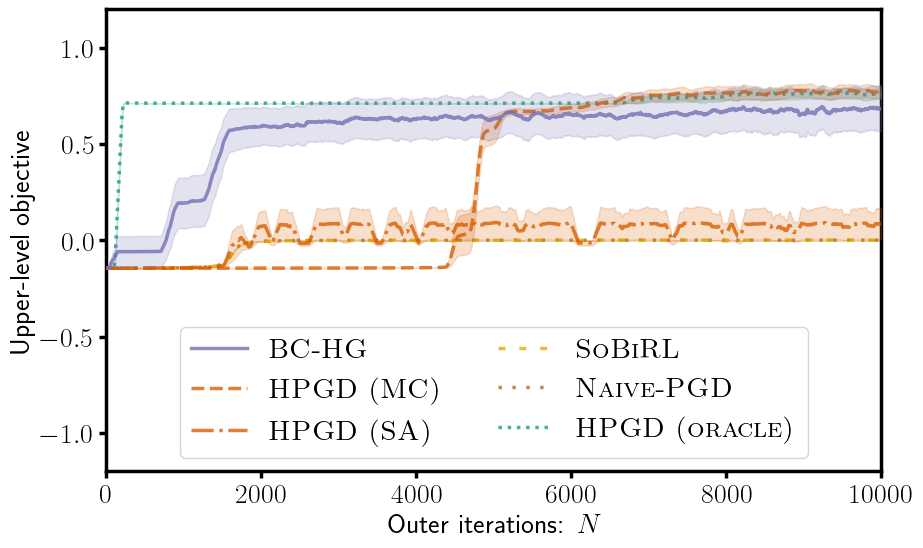


--- Reg_lambda: 2.0 ---


<Figure size 640x480 with 0 Axes>

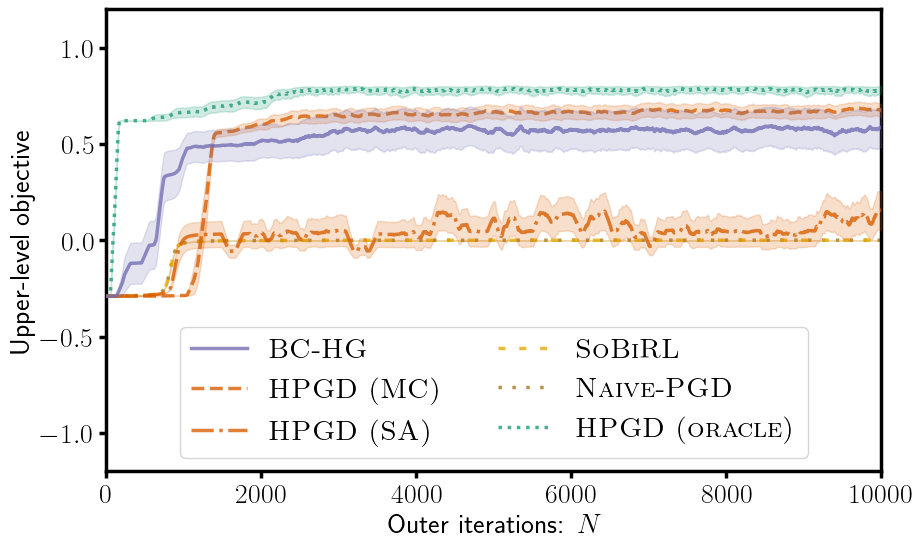


--- Reg_lambda: 3.0 ---


<Figure size 640x480 with 0 Axes>

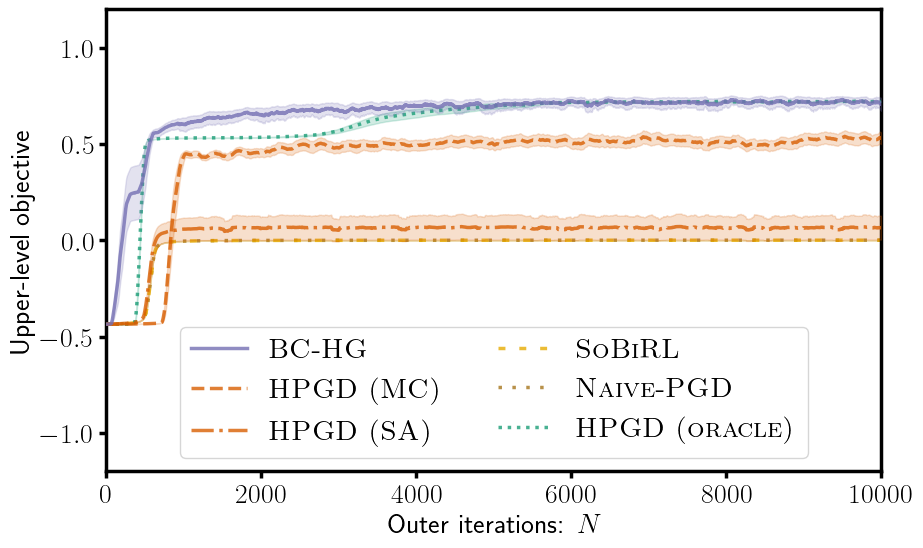


--- Reg_lambda: 4.0 ---


<Figure size 640x480 with 0 Axes>

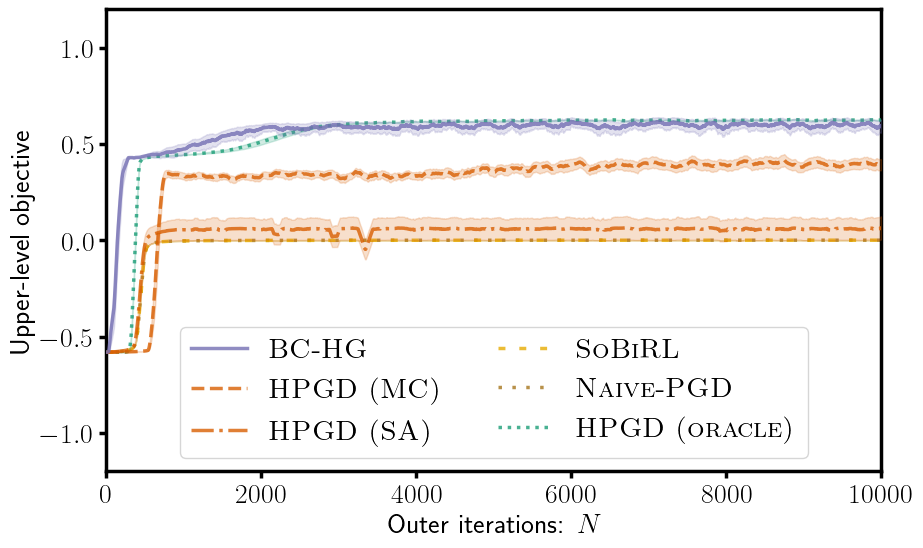


--- Reg_lambda: 5.0 ---


<Figure size 640x480 with 0 Axes>

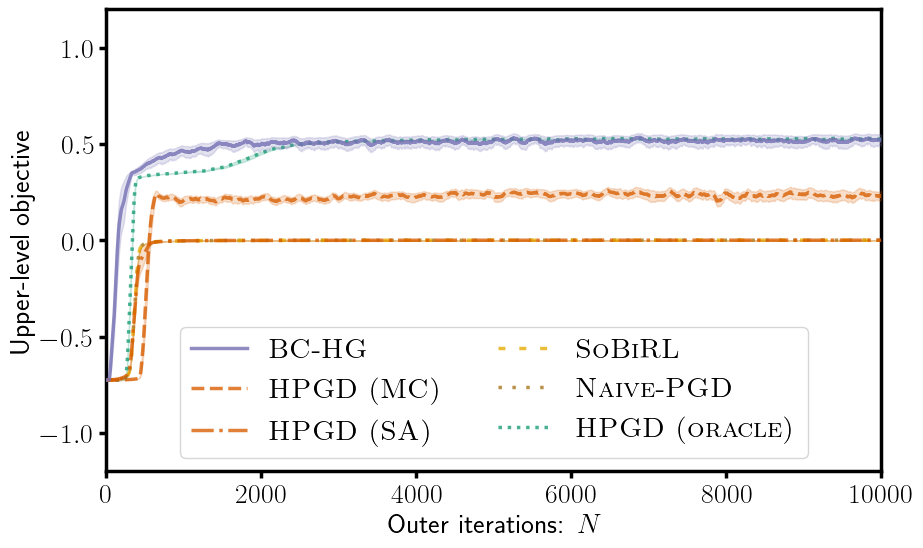

<Figure size 640x480 with 0 Axes>

In [5]:
y_lim = {
   1: (-1.2, 1.2),
   2: (-1.2, 1.2),
   3: (-1.2, 1.2),
   4: (-1.2, 1.2),
   5: (-1.2, 1.2),
}
if "0_005" in data_dir:
    y_lim = {
       1: (-1.2, 1.6),
       2: (-1.2, 1.6),
       3: (-1.2, 1.6),
       4: (-1.2, 1.6),
       5: (-1.2, 1.6),
    }

for reg_lambda in jnp.unique(grid_params["incentive_reg_grid"].values):
    reg_lambda = float(reg_lambda)
    print(f"\n--- Reg_lambda: {reg_lambda} ---")
    input_data = {}
    for algo in algorithms:
        if not algo in grid_search_params:
            print(f"Skipping {algo} as it is not in grid_search_params")
            continue
        df_grid_params = grid_search_params[algo]
        outputs = grid_search_outputs[algo]
        idx = (df_grid_params == best_parameters_for_reg_lambda[algo][reg_lambda]).all(1).values  # Shape: (n_grid_params,)
        input_data[algo] = outputs["UL_initial_value"][idx] if seed_idx is None else outputs["UL_initial_value"][idx][seed_idx].reshape(1,-1)  # Shape: (n_seeds, n_outer_iterations) or (1, n_outer_iterations)

    plot_UL_rewards(
        input_data,
        figsize=figsize,
        rolling_window=rolling_window,
        savefig_path=os.path.join(save_dir, f"UL_rewards_grid_search_reg_lambda_{reg_lambda}.pdf") if save_figures else None,
        xlim=(0, max_outer_iterations),
        ylim=y_lim[reg_lambda] if reg_lambda in y_lim else None,
        legend_position={
            "loc": "lower center",
            "bbox_to_anchor": (0.5, 0),
            "ncol": 2,
        },
        legend_names=legend_names,
        line_styles=line_styles,
        algo_colors=algo_colors,
        zorder=zorder,
        yscale="linear"
    )
    plt.close()
plt.clf()

# Visualize the penalty maps


--- Reg_lambda: 1.0 ---

--- proposal ---


Unused percentage: 0.0081%

--- hpgd ---
Unused percentage: 0.0299%

--- hpgd_sarsa ---
Unused percentage: 0.0279%

--- sobirl ---
Unused percentage: 99.8313%

--- baseline ---
Unused percentage: 99.8313%

--- hpgd_oracle ---
Unused percentage: 0.0003%


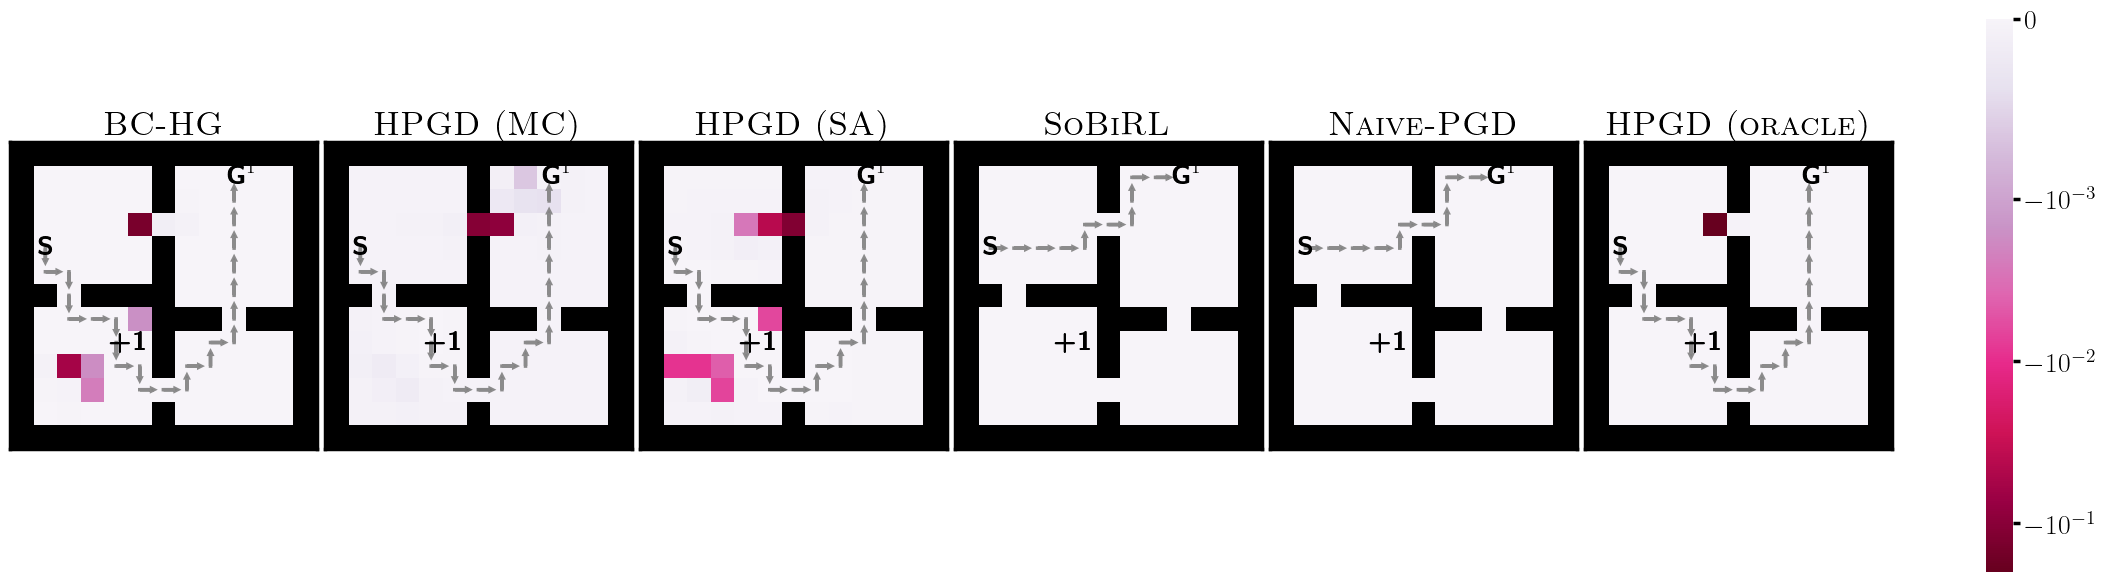


--- Reg_lambda: 2.0 ---

--- proposal ---
Unused percentage: 0.0016%

--- hpgd ---
Unused percentage: 0.0082%

--- hpgd_sarsa ---
Unused percentage: 0.1917%

--- sobirl ---
Unused percentage: 99.9237%

--- baseline ---
Unused percentage: 99.9237%

--- hpgd_oracle ---
Unused percentage: 0.0004%


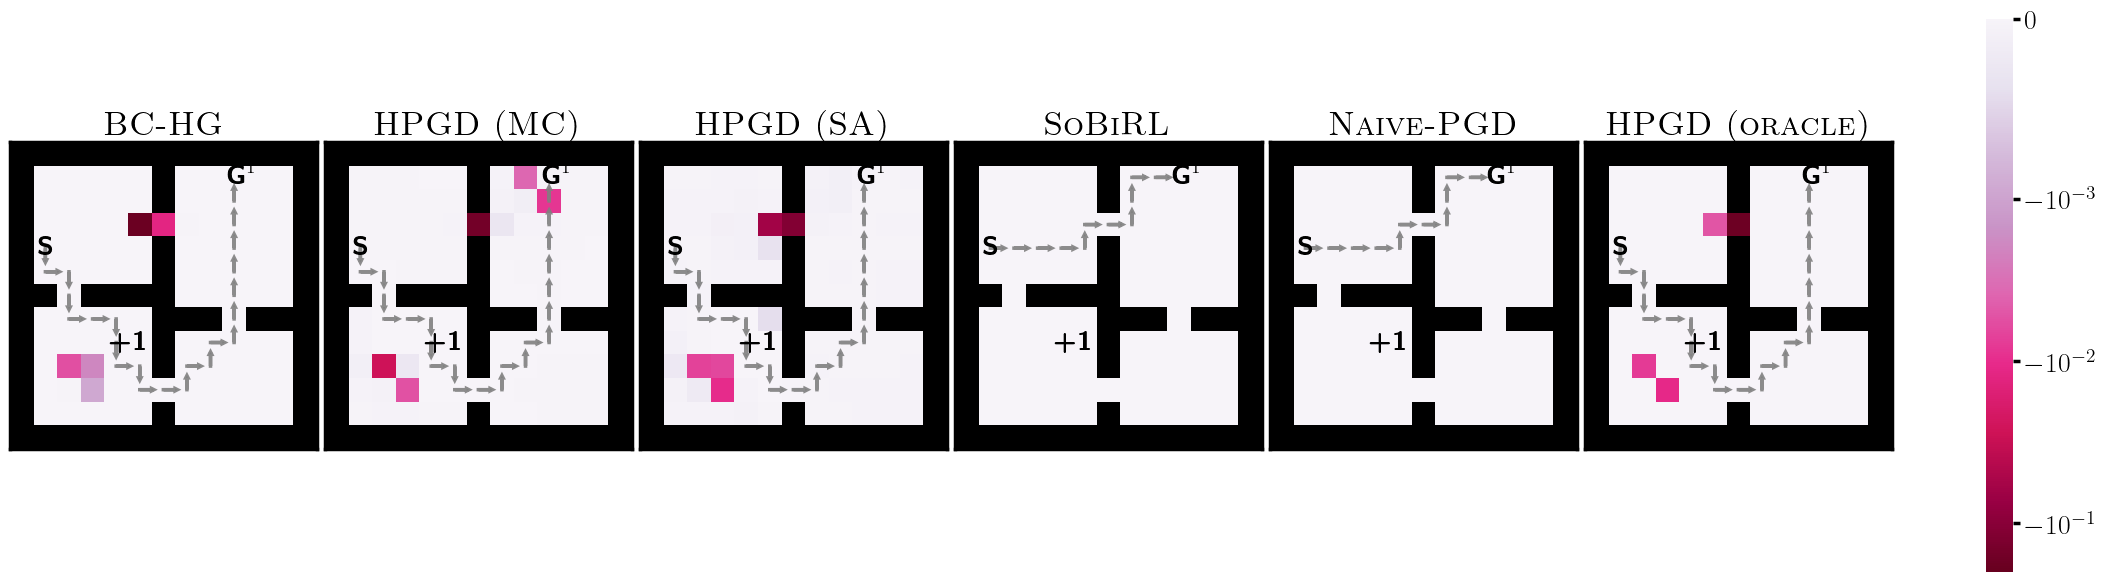


--- Reg_lambda: 3.0 ---

--- proposal ---
Unused percentage: 0.0075%

--- hpgd ---
Unused percentage: 0.0002%

--- hpgd_sarsa ---
Unused percentage: 99.9505%

--- sobirl ---
Unused percentage: 99.9506%

--- baseline ---
Unused percentage: 99.9506%

--- hpgd_oracle ---
Unused percentage: 0.0143%


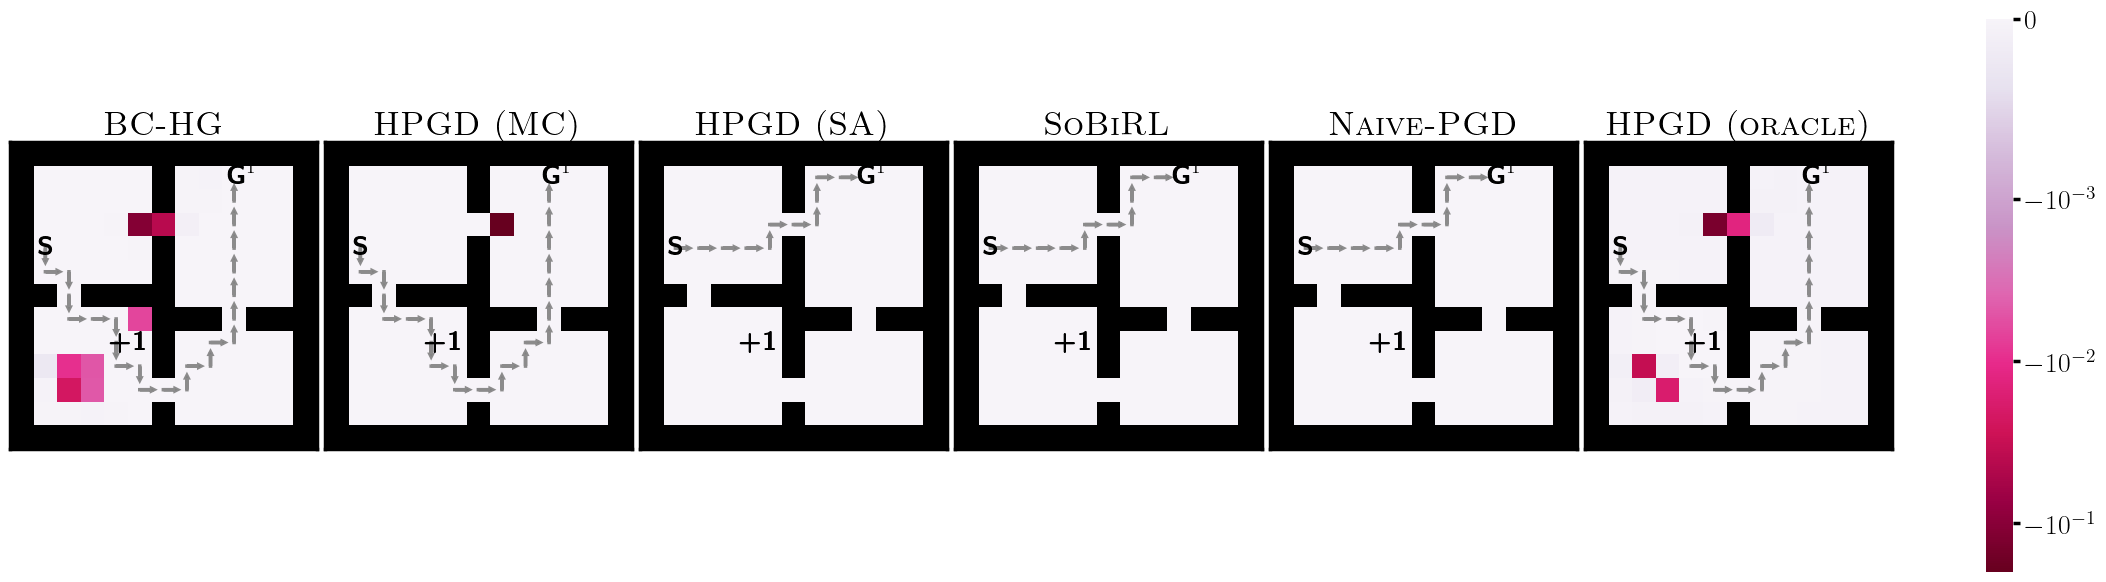


--- Reg_lambda: 4.0 ---

--- proposal ---
Unused percentage: 0.0038%

--- hpgd ---
Unused percentage: 0.0001%

--- hpgd_sarsa ---
Unused percentage: 99.9635%

--- sobirl ---
Unused percentage: 99.9635%

--- baseline ---
Unused percentage: 99.9635%

--- hpgd_oracle ---
Unused percentage: 0.0064%


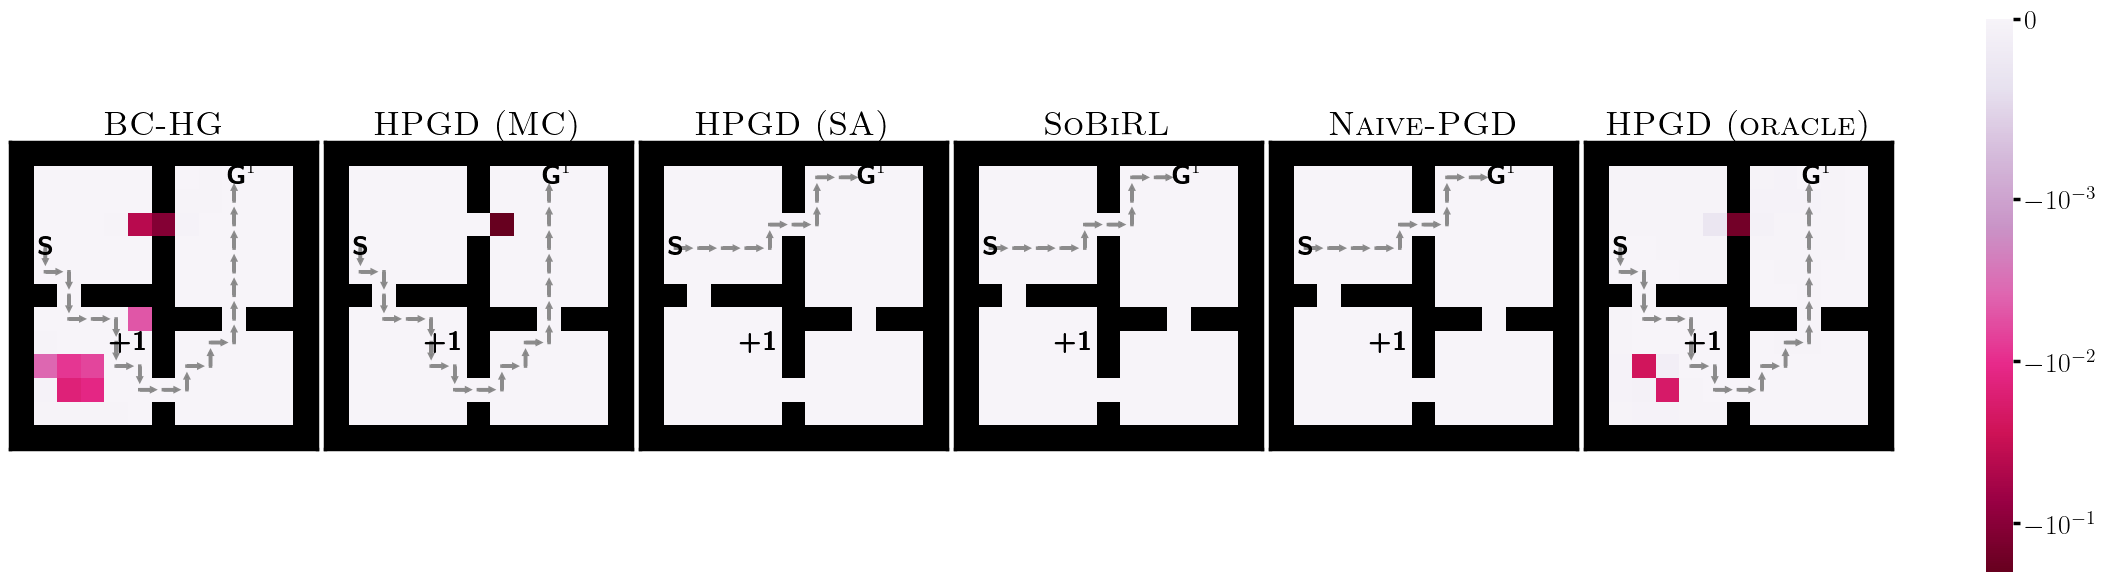


--- Reg_lambda: 5.0 ---

--- proposal ---
Unused percentage: 0.0041%

--- hpgd ---
Unused percentage: 0.0052%

--- hpgd_sarsa ---
Unused percentage: 99.9710%

--- sobirl ---
Unused percentage: 99.9711%

--- baseline ---
Unused percentage: 99.9711%

--- hpgd_oracle ---
Unused percentage: 0.0066%


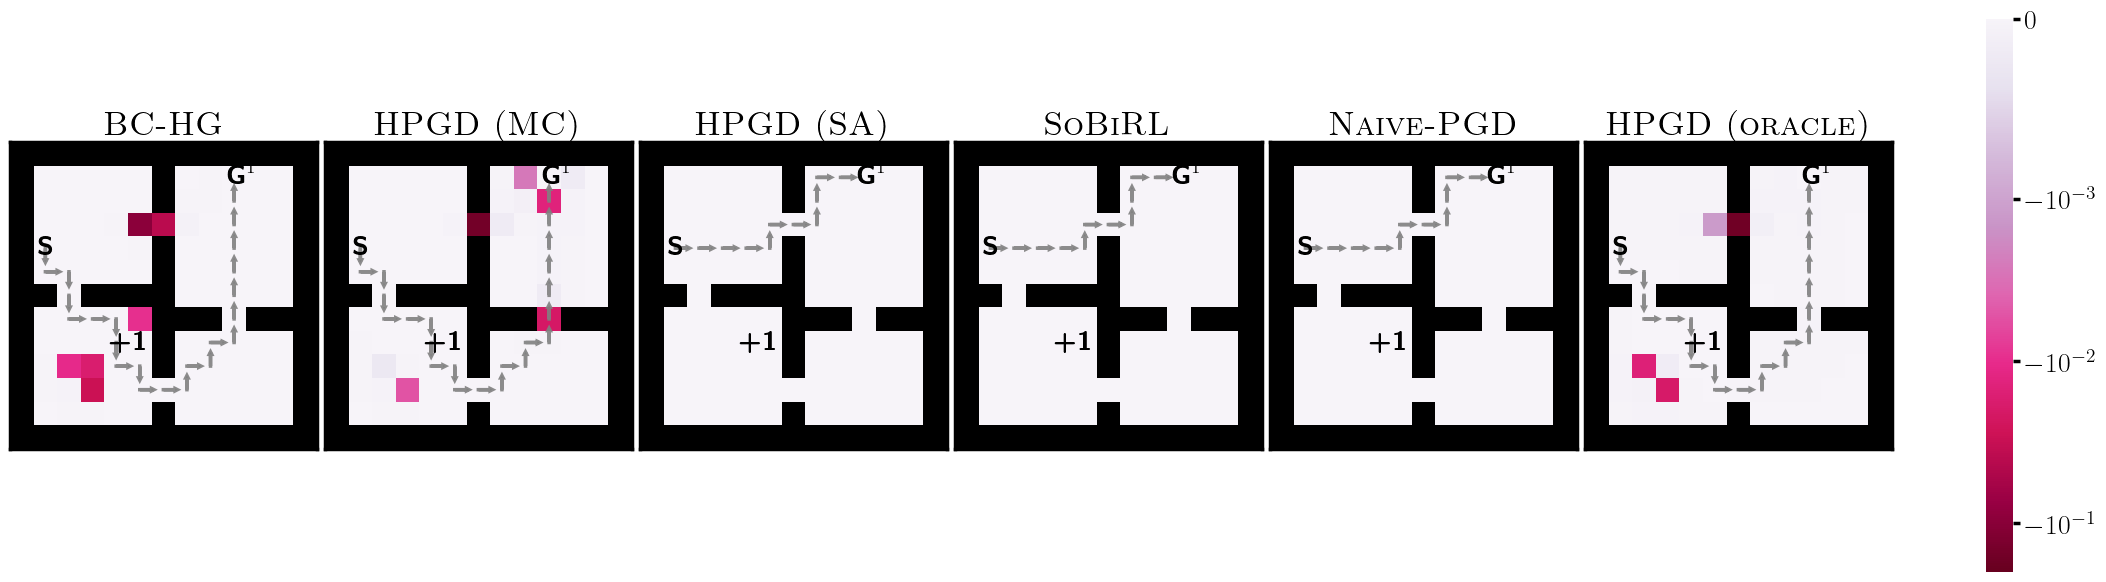

In [6]:
seed_idx = 0 if seed_idx is None else seed_idx
from src.environments.ConfigurableFourRooms import map_project
for reg_lambda in jnp.unique(grid_params["incentive_reg_grid"].values):
    reg_lambda = float(reg_lambda)
    config_tmp = config.copy()
    config_tmp["upper_optimisation"]["incentive_reg_param"] = 1.0
    print(f"\n--- Reg_lambda: {reg_lambda} ---")
    input_data = {}
    for algo in algorithms:
        df_grid_params = grid_search_params[algo]
        train_state = grid_search_train_states[algo]
        idx = (df_grid_params == best_parameters_for_reg_lambda[algo][reg_lambda]).all(1).values  # Shape: (n_grid_params,)
        input_data[algo] = jax.tree_map(lambda x: jnp.array(x)[idx], train_state["params"])

    fig, axes = plt.subplots(1, len(input_data), figsize=(21, 7), constrained_layout=True)

    # Ensure axes is always a list
    if len(input_data) == 1:
        axes = [axes]

    for i, (algo, incentive_train_state) in enumerate(input_data.items()):
        print(f"\n--- {algo} ---")
        axes[i].set_title(legend_names[algo])
        pcm = plot_incentive_grid(
            env,
            env_params,
            incentive_train_state["params"]["weights"][seed_idx],
            config_incentive["coordinates"],
            config_tmp,
            verbose=False,
            plot_input=(fig, axes[i]),
            cmap="PuRd_r",
        )

        # Add policy steps to the map
        init_probs = env.state_initialization_distribution(env_params.state_initialization_params).probs
        init_probs_mask = init_probs > 1e-8
        env_params_viz = env_params.replace(
            incentive_params=jax.tree_map(lambda x: x[seed_idx], incentive_train_state)
        )
        config_lower_level = config["lower_optimisation"]
        q_final, _ = general_value_iteration(
            env,
            env_params_viz,
            config_lower_level["discount_factor"],
            n_policy_iter=config_lower_level["n_policy_iter"],
            n_value_iter=config_lower_level["n_value_iter"],
            regularization=config_lower_level["regularization"],
            reg_lambda=config_lower_level["reg_lambda"],
            return_q_value=True,
        )
        br_policy = jax.nn.softmax(q_final/config_lower_level["reg_lambda"], axis=-1)  # Shape: (n_goals, n_states, n_actions)
        for j in range(len(env.available_goals)):
            goal_pos = jnp.array(config["environment"]["available_goals"][j])
            pos = env.available_init_pos[init_probs_mask][0]
            # Add the policy trajectories to the map
            for _ in range(30):
                try:
                    pos_idx = jnp.where(jnp.all(env.coords == pos[None, :], 1))[0][0]
                except:
                    print(pos)
                    break
                action_sort = jnp.argsort(br_policy[j, pos_idx])[::-1]
                for action in action_sort:  # 確率が高い行動から順に試し、最初に移動できる行動を選択
                    action_direction = env.directions[action]
                    new_pos = map_project(env.env_map, pos, pos + action_direction)
                    if not jnp.all(new_pos == pos):
                        break
                color = "gray"
                axes[i].arrow(
                    pos[1],
                    pos[0],
                    action_direction[1]/2.0,
                    action_direction[0]/2.0,
                    head_width=0.1,
                    head_length=0.1,
                    linewidth=linewidth,
                    fc=color,
                    ec=color,
                    alpha=0.9,
                )
                pos = new_pos
                if jnp.all(pos == goal_pos):
                    break


        # Add goal and initial position annotations
        for j in range(len(env.available_goals)):
            goal_pos = config["environment"]["available_goals"][j]
            axes[i].annotate(
                rf"$\textbf{{G}}^{j+1}$",
                xy=(goal_pos[1], goal_pos[0]),
                xycoords="data",
                xytext=(goal_pos[1] - 0.3, goal_pos[0] + 0.25),
            )
        init_states_counter = 1
        for pos in env.available_init_pos[init_probs_mask]:
            axes[i].annotate(
                rf"$\textbf{{S^{init_states_counter}}}$" if sum(init_probs_mask) > 1 else rf"$\textbf{{S}}$",
                # fontsize=20,
                weight="bold",
                xy=(pos[1], pos[0]),
                xycoords="data",
                xytext=(pos[1]-0.3, pos[0]+0.25),

            )
            init_states_counter += 1
        pos = config["upper_optimisation"]["reward_function"]["target_state"]
        axes[i].annotate(
            rf"$\textbf{{+1}}$" if config["upper_optimisation"]["reward_function"]["type"] == "positive" else rf"$\textbf{{-1}}$",
            # fontsize=20,
            weight="bold",
            xy=(pos[1], pos[0]),
            xycoords="data",
            xytext=(pos[1]-0.3, pos[0]+0.25),
        )
        # Calculate the upper_level_value
        unused_pct = 100*jax.nn.softmax(incentive_train_state['params']['weights'][seed_idx])[-1]
        print(f"Unused percentage: {unused_pct:.4f}%")
    ax_list = axes if isinstance(axes, list) else axes.ravel().tolist() if hasattr(axes, 'ravel') else [axes]
    cbar = fig.colorbar(pcm, ax=ax_list, shrink=0.8)
    cbar.outline.set_visible(False)
    #plt.subplots_adjust(right=0.98)
    if save_figures:
        fig.savefig(os.path.join(save_dir, f"incentive_grid_grid_search_seed_{seed_idx}_reg_lambda_{reg_lambda}.pdf"), bbox_inches='tight')
    plt.show()
    plt.close()